# Local Friendliness violations with Agents on Quantum Computers

This notebook guides through the full pipeline of the project:
1. Circuit construction
2. Noiseless (ideal) simulation
3. Transpilation for IBM quantum hardware
4. Fake-hardware simulations
5. Real hardware runs on IBM quantum computers

## 1. Circuit construction

The agent circuits are constructed from the builders in `ewfs/circuits/agents.py`. The plotting helper is shared with the noiseless simulation script, but here it returns matplotlib figures directly instead of saving them to disk. The notebook display uses a large fold value instead of the thesis-specific `fold=18`, so the circuits are shown in a wider layout.

In [14]:
from pathlib import Path
import os
import sys
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
warnings.filterwarnings("ignore", message="Using qiskit-ibm-runtime with Python 3.9 is deprecated.*")

import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = next(
    (path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (path / "ewfs").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the project root containing the 'ewfs' package. Start Jupyter from this repository.")

SRC_ROOT = PROJECT_ROOT / "src"
sys.path = [path for path in sys.path if Path(path or ".").resolve() != SRC_ROOT]
sys.path.insert(0, str(PROJECT_ROOT))
for module_name in list(sys.modules):
    if module_name == "ewfs" or module_name.startswith("ewfs."):
        del sys.modules[module_name]

try:
    import pylatexenc  # noqa: F401
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Qiskit's matplotlib circuit drawer needs pylatexenc. Install it in this notebook kernel with: "
        "%pip install pylatexenc==2.10"
    ) from exc

NOTEBOOK_CIRCUIT_FOLD = 100

from ewfs.circuits.agents import AGENTS
from ewfs.experiments.noiseless_simulation import (
    make_circuit_plot_figure,
    run_noiseless_simulation,
)
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh
from ewfs.analysis.lf_violations import S as lf_violation
from ewfs.experiments.ibm_transpilation import (
    make_transpiled_plot_figure,
    transpile_agent_circuit,
    transpiled_circuit_metrics,
)
from ewfs.experiments.fake_hardware import run_fake_hardware_for_backend

Reflex Agent


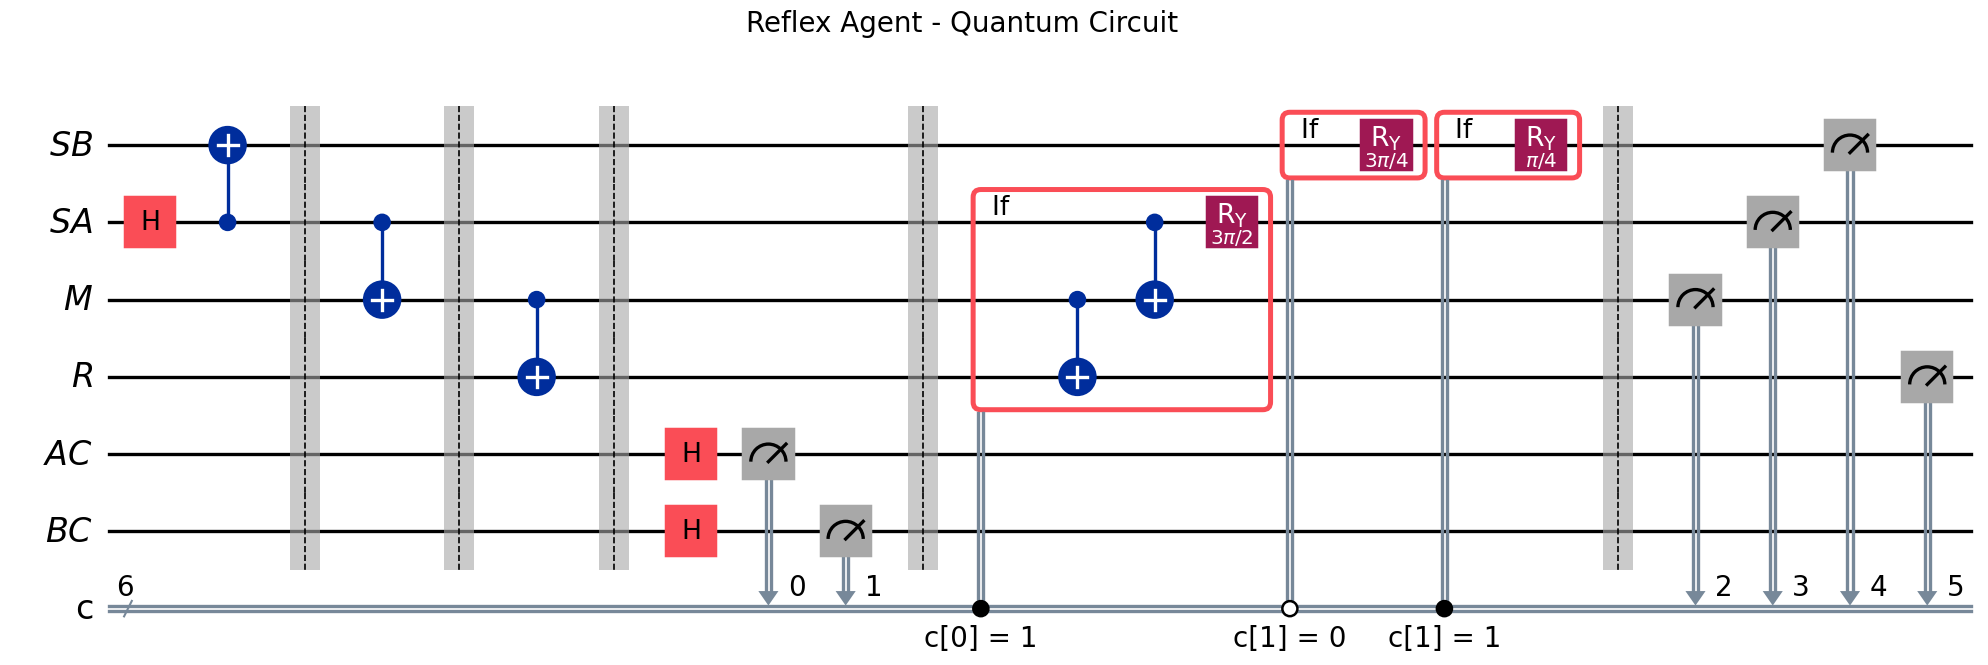

Guessing Agent


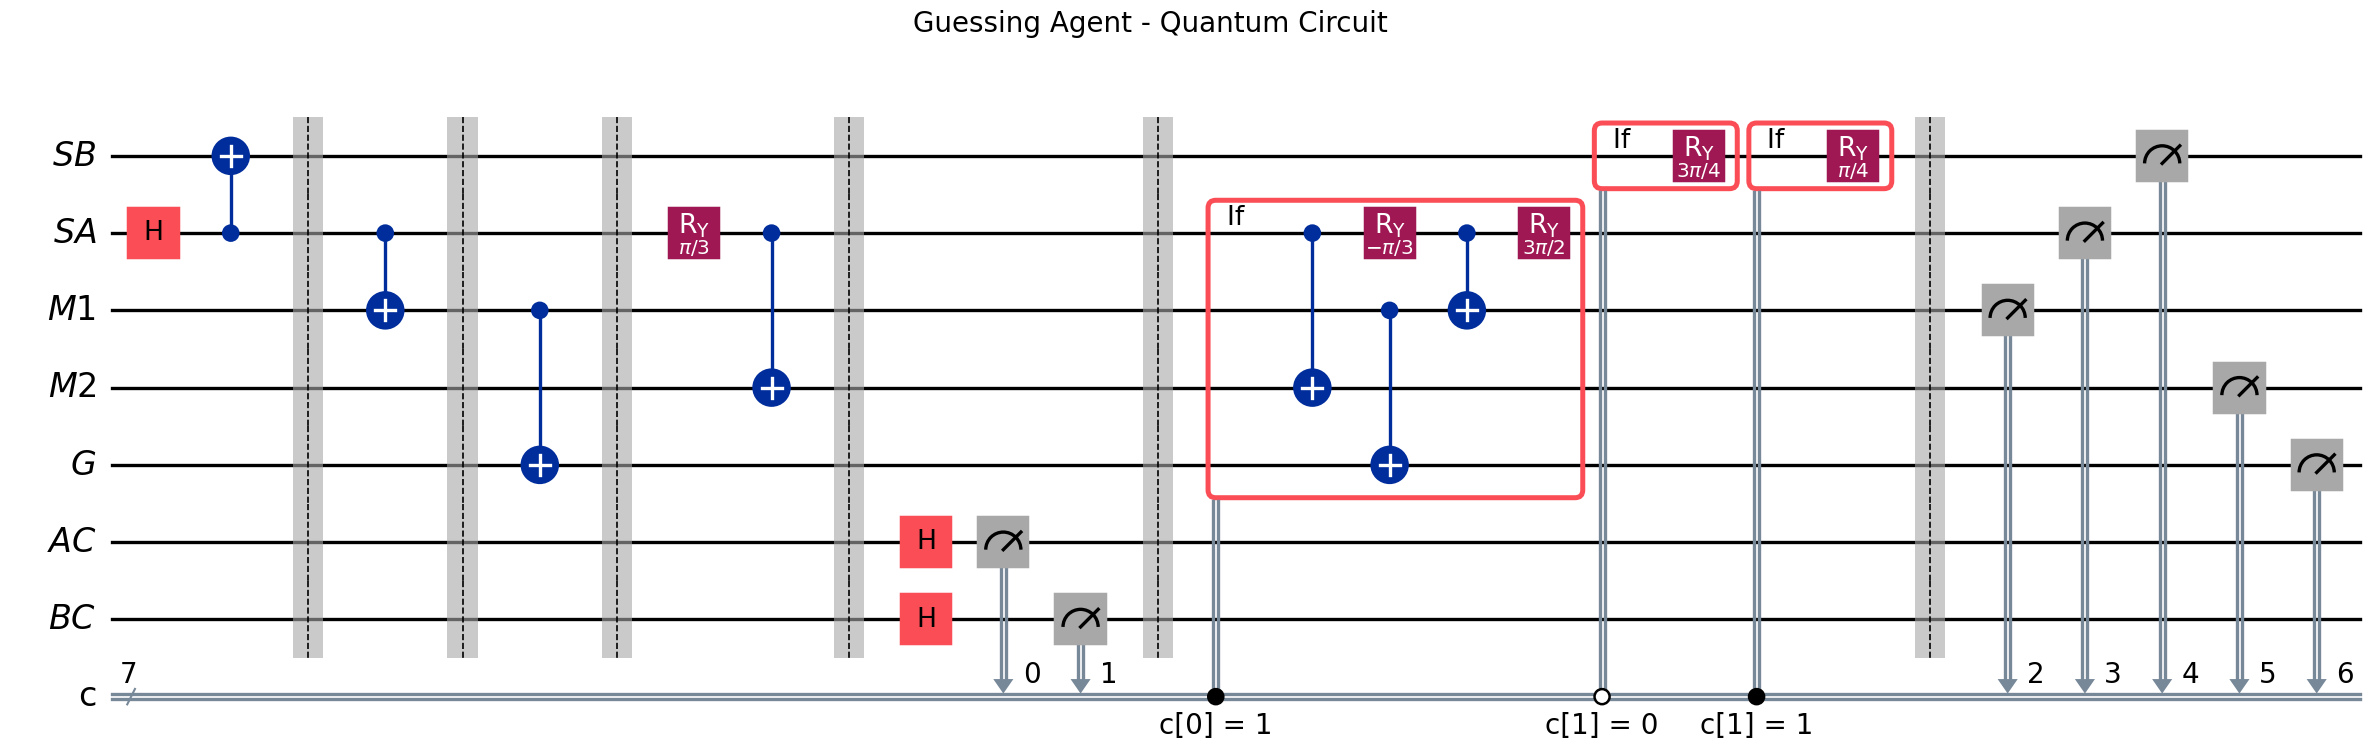

Betting Agent


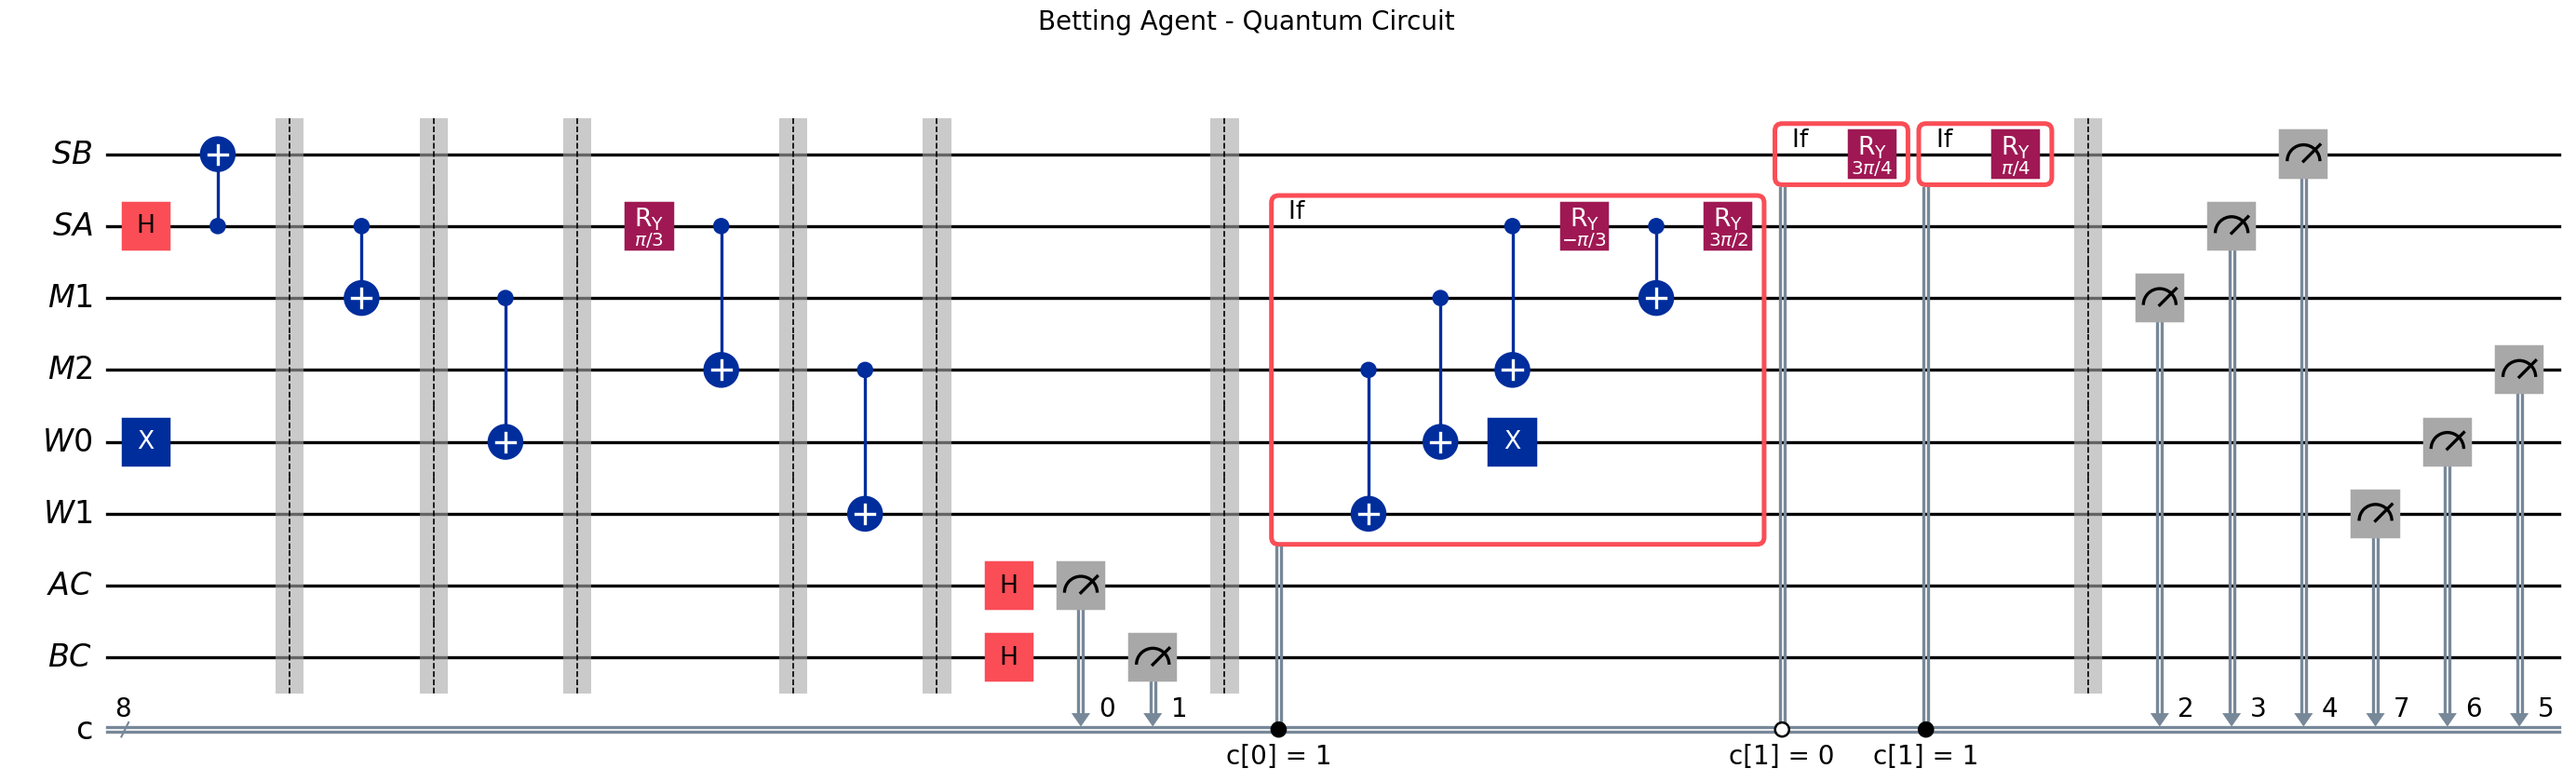

Always 3/4 Agent


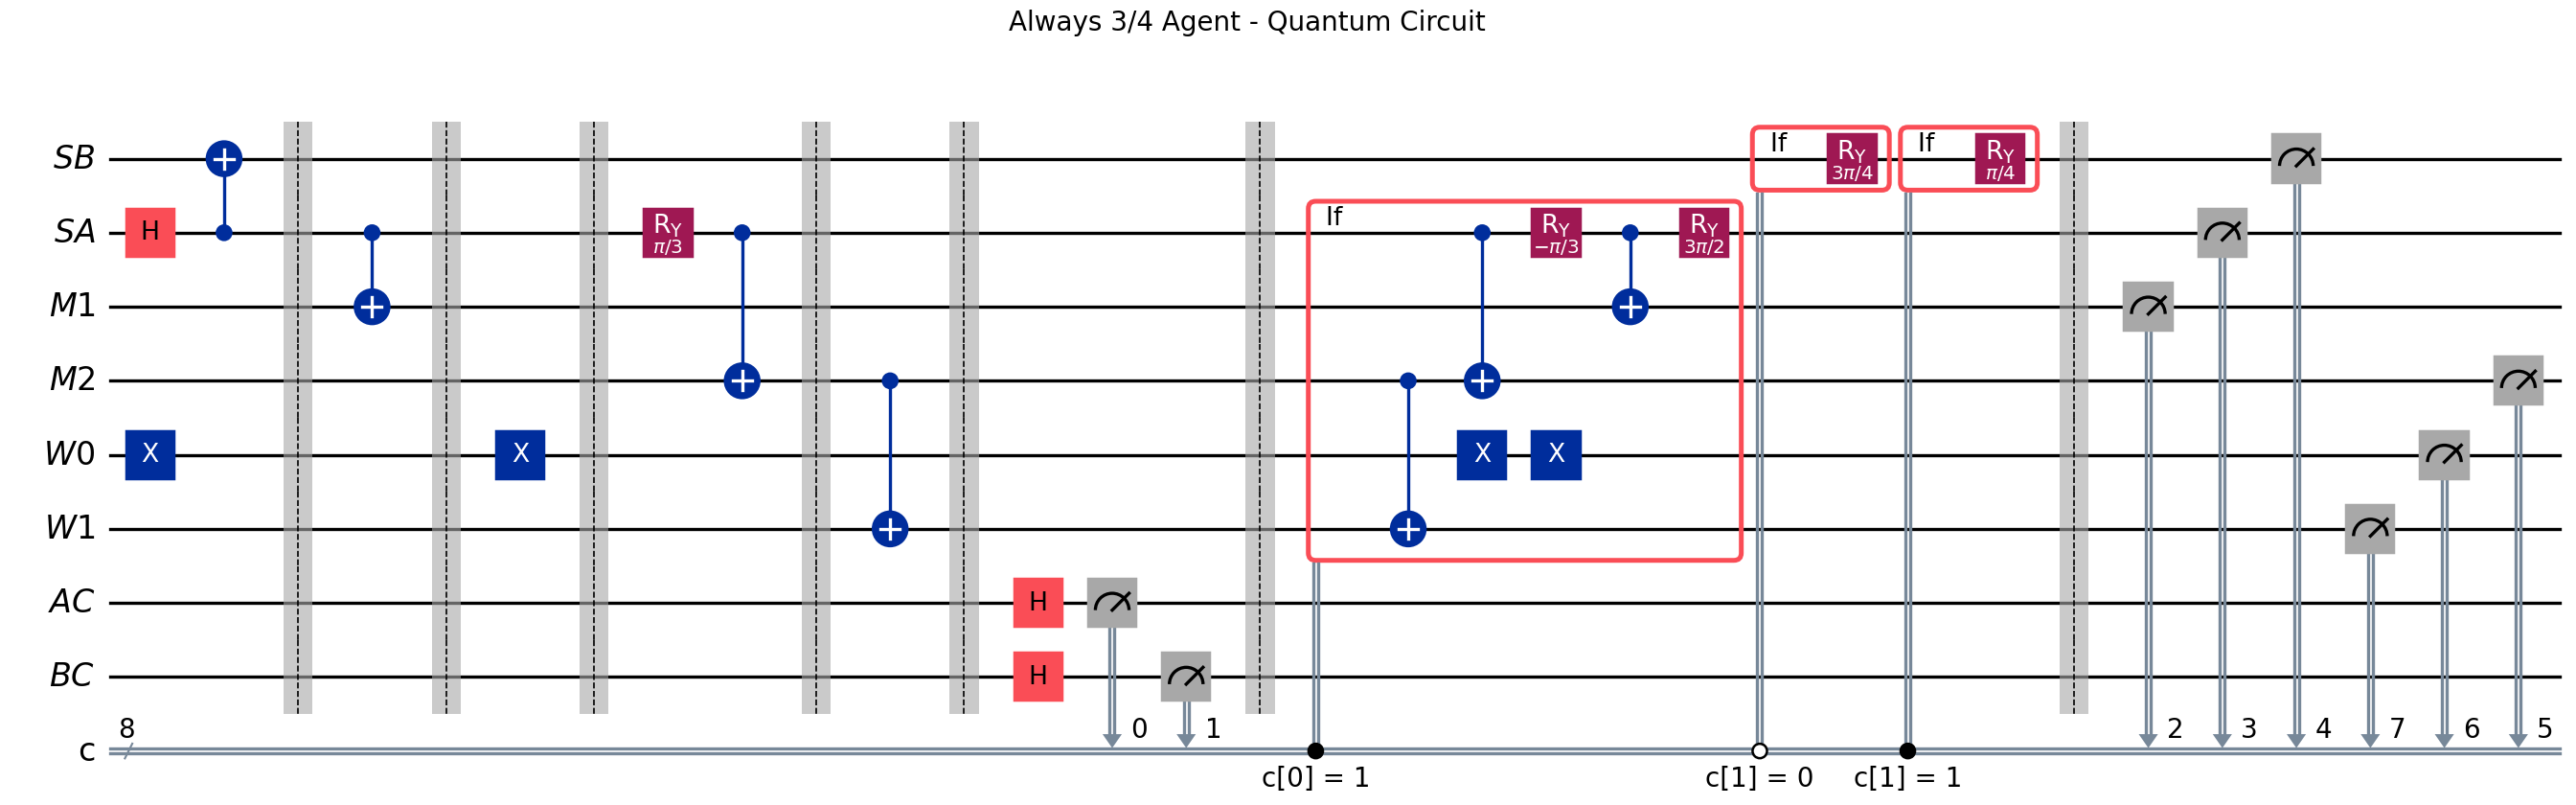

In [15]:
circuits = {}

for agent_name, build_circuit in AGENTS:
    circuit = build_circuit()
    circuits[agent_name] = circuit

    print(agent_name)
    fig = make_circuit_plot_figure(circuit, agent_name, fold=NOTEBOOK_CIRCUIT_FOLD)
    display(fig)
    plt.close(fig)

## 2. Noiseless simulation

For the notebook demo, the same noiseless simulation runner is called with `save=False` and `make_plots=False`. This keeps the notebook interactive: data is returned in memory, and the LF value is calculated directly from the returned counts.

In [16]:
noiseless_results = run_noiseless_simulation(
    shots=100_000,
    save=False,
    make_plots=False,
    agent_builders=AGENTS,
)

print("\nLF violation values from the noiseless simulation:")
for agent_name, agent_data in noiseless_results["agents"].items():
    s_value = lf_violation(agent_data["counts"])
    print(f"  {agent_name}: S = {s_value:.4f}")


=== Noiseless simulation ===
Shots: 100000
  Reflex Agent: done
  Guessing Agent: done
  Betting Agent: done
  Always 3/4 Agent: done

LF violation values from the noiseless simulation:
  Reflex Agent: S = 0.8349
  Guessing Agent: S = 0.8318
  Betting Agent: S = 0.8326
  Always 3/4 Agent: S = 0.8325


## 3. Transpilation

The circuits are transpiled for the IBM Marrakesh backend using the same manual layout and optimization settings as `ewfs/experiments/ibm_transpilation.py`. For the notebook demo, plots are displayed inline with the wide notebook fold setting and are not saved to disk.

Transpiling for backend: fake_marrakesh
  Reflex Agent: transpiling
    initial_layout=[10, 11, 12, 13, 0, 155]
    depth=28, cz=3


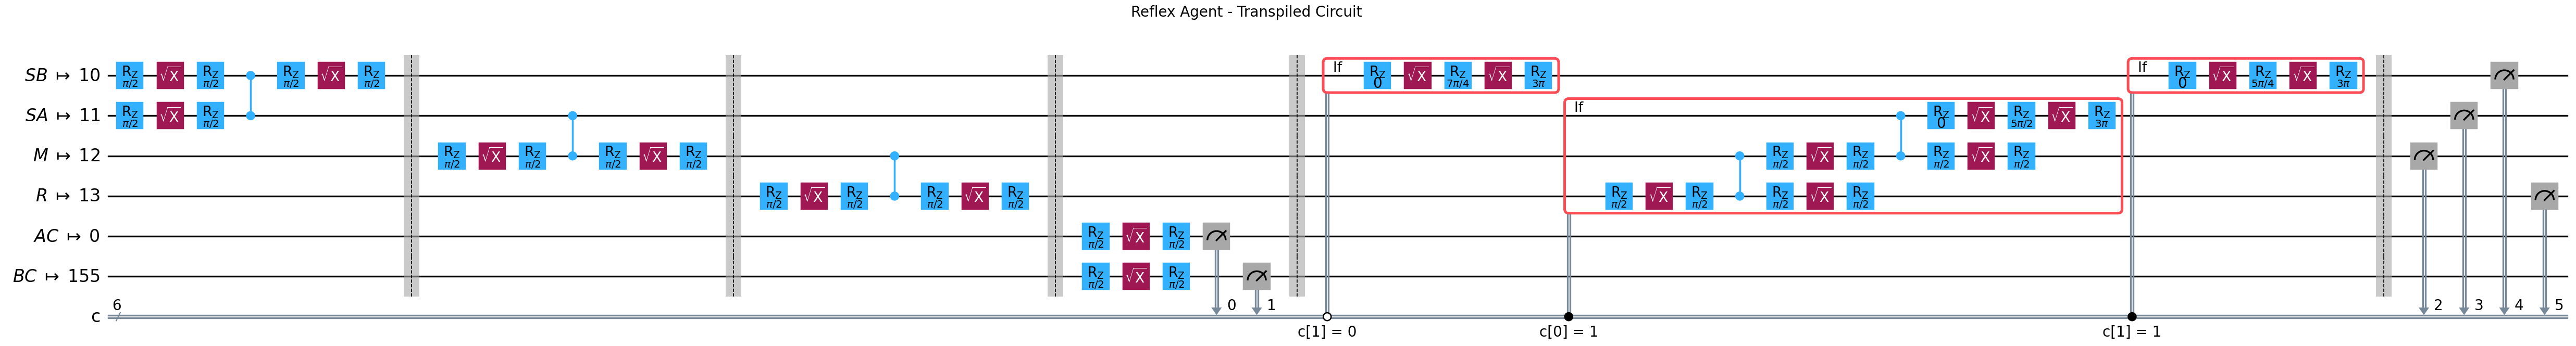

  Guessing Agent: transpiling
    initial_layout=[10, 11, 12, 18, 13, 0, 155]
    depth=37, cz=4


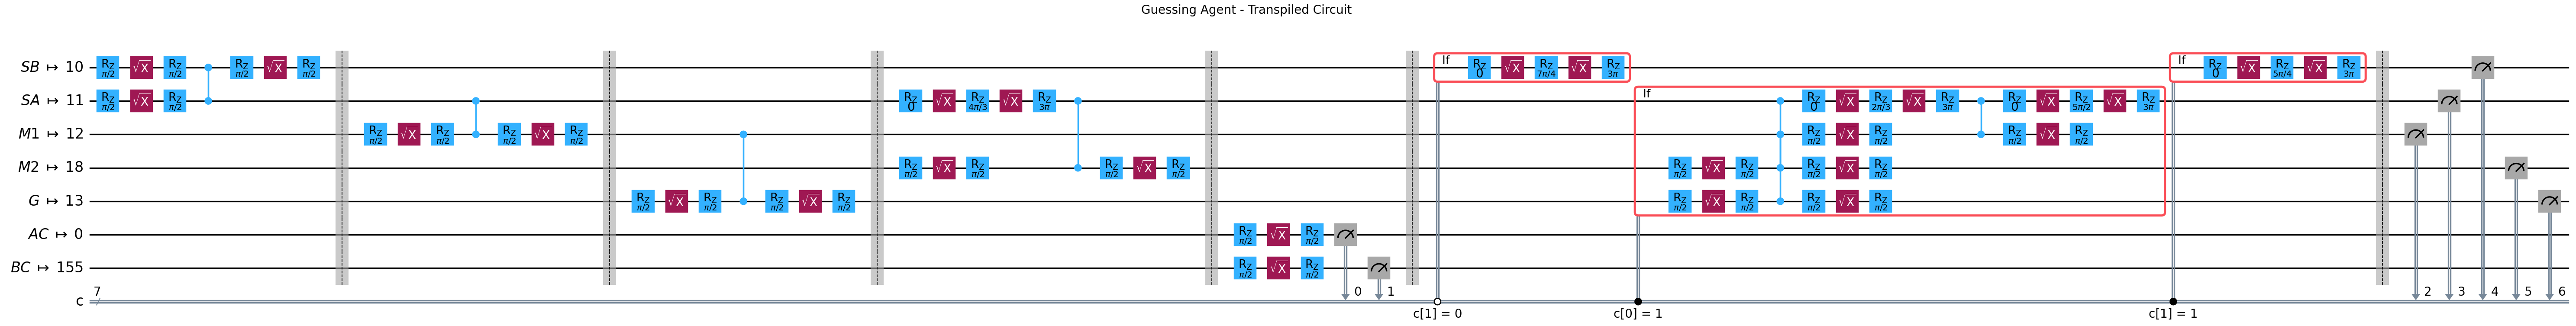

  Betting Agent: transpiling
    initial_layout=[18, 11, 12, 10, 13, 9, 0, 155]
    depth=44, cz=5


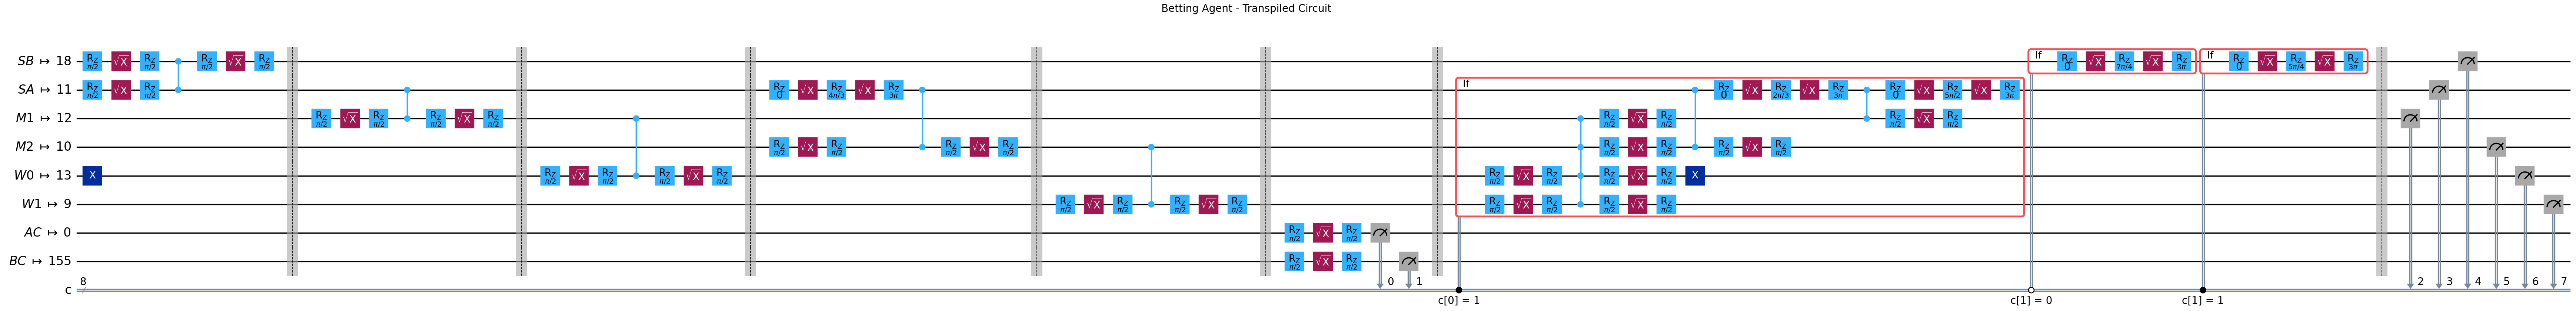

  Always 3/4 Agent: transpiling
    initial_layout=[18, 11, 12, 10, 13, 9, 0, 155]
    depth=38, cz=4


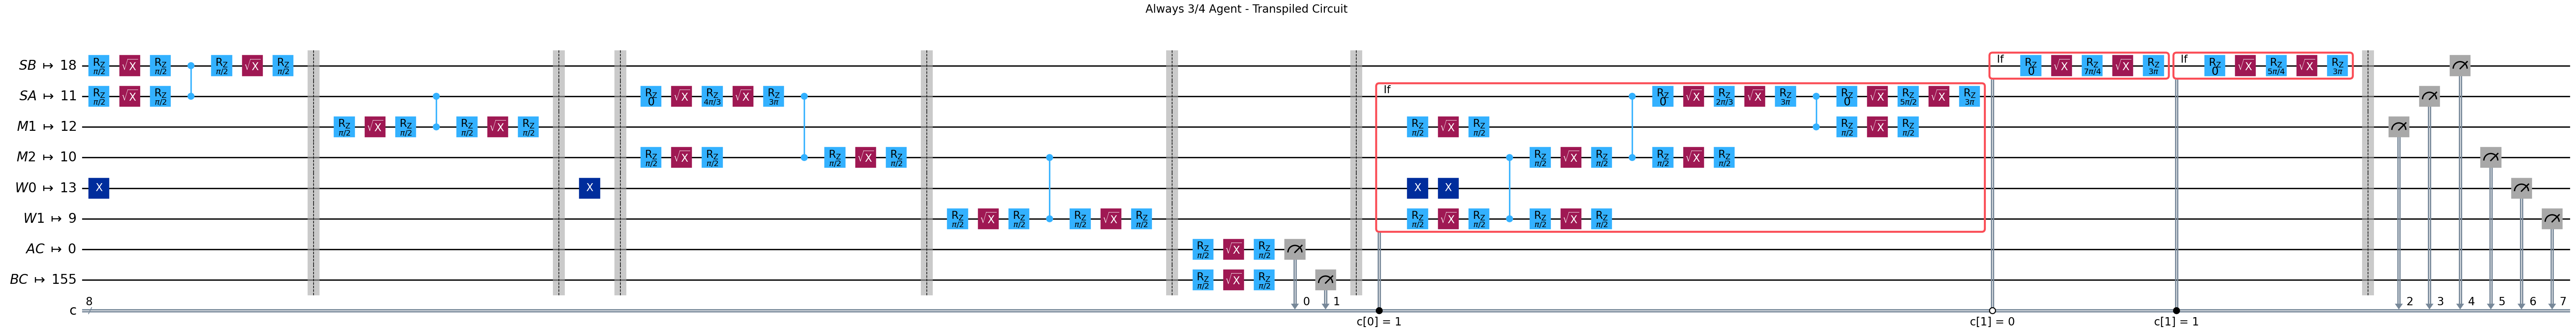

In [17]:
transpilation_backend = FakeMarrakesh()
transpiled_circuits = {}
transpilation_metrics = []

print(f"Transpiling for backend: {transpilation_backend.name}")
for agent_name, build_circuit in AGENTS:
    original_circuit = circuits.get(agent_name) or build_circuit()
    transpiled_circuit = transpile_agent_circuit(
        agent_name=agent_name,
        build_fn=build_circuit,
        backend=transpilation_backend,
        save_plots=False,
    )
    transpiled_circuits[agent_name] = transpiled_circuit
    transpilation_metrics.append(transpiled_circuit_metrics(agent_name, transpiled_circuit))

    fig = make_transpiled_plot_figure(
        original_circuit,
        transpiled_circuit,
        agent_name,
        fold=NOTEBOOK_CIRCUIT_FOLD,
    )
    display(fig)
    plt.close(fig)


## 4. Fake-hardware simulation

The transpiled circuits are simulated with the fake IBM Marrakesh noise model. As in the noiseless section, the notebook keeps the counts in memory and prints the LF value for each agent without saving a JSON file.

In [18]:
if "transpilation_backend" not in globals():
    transpilation_backend = FakeMarrakesh()

if "transpiled_circuits" not in globals():
    transpiled_circuits = {
        agent_name: transpile_agent_circuit(
            agent_name=agent_name,
            build_fn=build_circuit,
            backend=transpilation_backend,
            save_plots=False,
        )
        for agent_name, build_circuit in AGENTS
    }

fake_hardware_results = run_fake_hardware_for_backend(
    backend=transpilation_backend,
    transpiled_by_agent=transpiled_circuits,
    shots=10_000,
    save=False,
)

print("\nLF violation values from the fake-hardware simulation:")
for agent_name, agent_data in fake_hardware_results["agents"].items():
    s_value = lf_violation(agent_data["counts"])
    print(f"  {agent_name}: S = {s_value:.4f}")



=== Fake hardware simulation ===
Backend: fake_marrakesh
Shots: 10000
  Reflex Agent: done
  Guessing Agent: done
  Betting Agent: done
  Always 3/4 Agent: done

LF violation values from the fake-hardware simulation:
  Reflex Agent: S = 0.7178
  Guessing Agent: S = 0.7369
  Betting Agent: S = 0.6785
  Always 3/4 Agent: S = 0.7881
